## Imports + Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
master_df = pd.read_csv(os.path.join(base_dir, 'data', 'processed', 'master_df.csv'), index_col=0)

print("✅ Libraries loaded")
print(f"✅ master_df loaded — {master_df.shape}")

✅ Libraries loaded
✅ master_df loaded — (3, 19)


## Build Historical + Forecast Data

In [2]:
# Historical revenue index (2019 = 100 baseline)
# Sources: IHRSA, IBISWorld, Peloton/Beachbody filings
years_hist = np.array([2019, 2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
years_fore = np.array([2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
years_all  = np.concatenate([years_hist, years_fore])

revenue_data = {
    'HVLP': {
        'hist': [100, 58, 82, 96, 107, 118],   # COVID dip, strong recovery
        'cagr': 0.067,                           # 6.7% SS growth from master_df
    },
    'Boutique': {
        'hist': [100, 42, 71, 88, 94, 99],      # harder COVID hit, slower recovery
        'cagr': 0.005,                           # 0.5% from master_df
    },
    'Digital': {
        'hist': [100, 198, 210, 175, 152, 140], # COVID spike then decline
        'cagr': -0.03,                           # -3% from master_df
    },
}

# Fit polynomial regression on historical, project forward
models = {}
for cat, d in revenue_data.items():
    hist_vals = np.array(d['hist'])
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(years_hist)
    model = LinearRegression().fit(X_poly, hist_vals)
    models[cat] = (model, poly)

    # Forecast using CAGR from last historical point
    last_val = d['hist'][-1]
    forecast = [last_val * (1 + d['cagr']) ** i for i in range(1, 7)]
    d['forecast'] = forecast

    r2 = r2_score(hist_vals, model.predict(X_poly))
    print(f"{cat:<10}  Last known: {last_val}  |  2030 forecast: {forecast[-1]:.1f}  |  R²: {r2:.3f}")

HVLP        Last known: 118  |  2030 forecast: 174.1  |  R²: 0.648
Boutique    Last known: 99  |  2030 forecast: 102.0  |  R²: 0.396
Digital     Last known: 140  |  2030 forecast: 116.6  |  R²: 0.693


## Revenue Forecast Chart

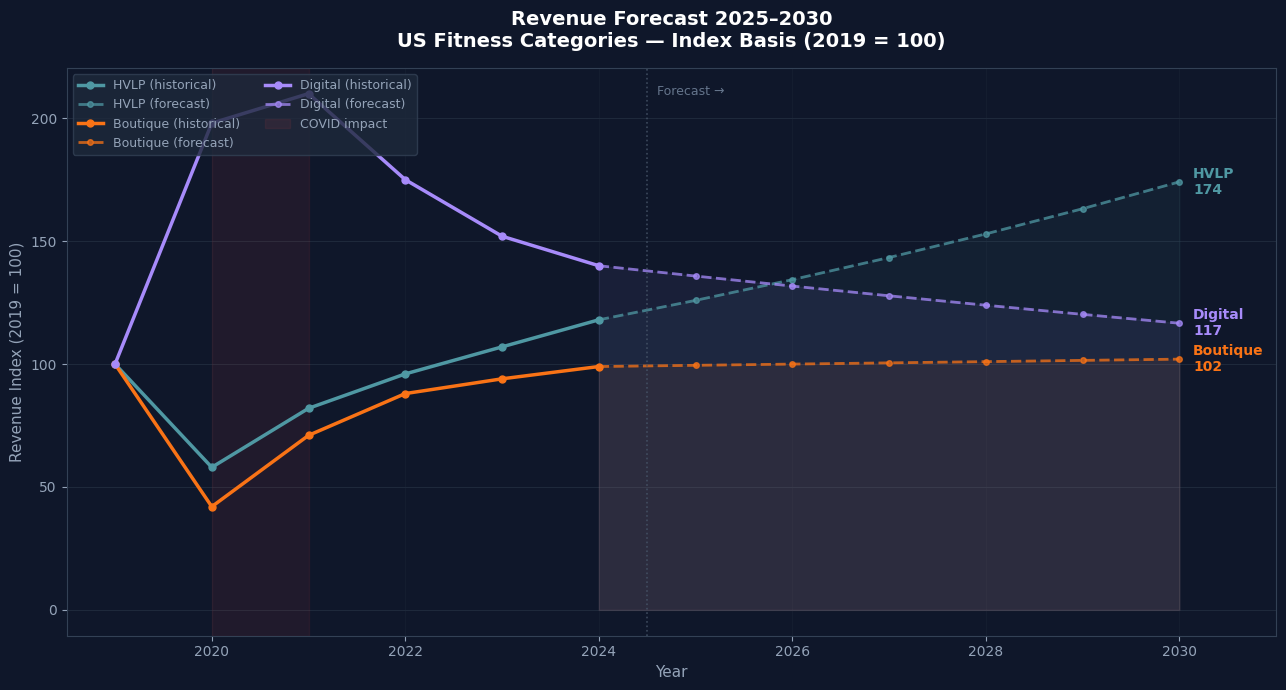

✅ Revenue forecast saved → output/revenue_forecast.png


In [3]:
colors = {'HVLP': '#4f98a3', 'Boutique': '#f97316', 'Digital': '#a78bfa'}

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

for cat, d in revenue_data.items():
    color = colors[cat]
    hist_years = years_hist.flatten()
    fore_years = years_fore.flatten()

    # Historical line — solid
    ax.plot(hist_years, d['hist'],
            color=color, linewidth=2.5, marker='o', markersize=5, label=f'{cat} (historical)')

    # Forecast line — dashed, connected from last historical point
    ax.plot([hist_years[-1]] + list(fore_years),
            [d['hist'][-1]] + d['forecast'],
            color=color, linewidth=2, linestyle='--', marker='o',
            markersize=4, alpha=0.75, label=f'{cat} (forecast)')

    # Shade forecast region
    ax.fill_between(
        [hist_years[-1]] + list(fore_years),
        [d['hist'][-1]] + d['forecast'],
        alpha=0.07, color=color
    )

    # 2030 label
    ax.annotate(
        f"{cat}\n{d['forecast'][-1]:.0f}",
        xy=(2030, d['forecast'][-1]),
        xytext=(10, 0), textcoords='offset points',
        color=color, fontsize=10, fontweight='bold', va='center'
    )

# COVID shading
ax.axvspan(2020, 2021, alpha=0.08, color='#ef4444', label='COVID impact')
ax.axvline(x=2024.5, color='#475569', linewidth=1.2, linestyle=':', alpha=0.8)
ax.text(2024.6, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 220,
        'Forecast →', color='#64748b', fontsize=9)

ax.set_xlim(2018.5, 2031)
ax.set_xlabel('Year', color='#94a3b8', fontsize=11)
ax.set_ylabel('Revenue Index (2019 = 100)', color='#94a3b8', fontsize=11)
ax.set_title('Revenue Forecast 2025–2030\nUS Fitness Categories — Index Basis (2019 = 100)',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#94a3b8')
ax.yaxis.grid(True, color='#1e293b', linewidth=0.8)
ax.xaxis.grid(True, color='#1e293b', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_edgecolor('#334155')

legend = ax.legend(loc='upper left', facecolor='#1e293b',
                   edgecolor='#334155', fontsize=9, ncol=2)
for text in legend.get_texts():
    text.set_color('#94a3b8')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'revenue_forecast.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Revenue forecast saved → output/revenue_forecast.png")

## CAGR Summary Table

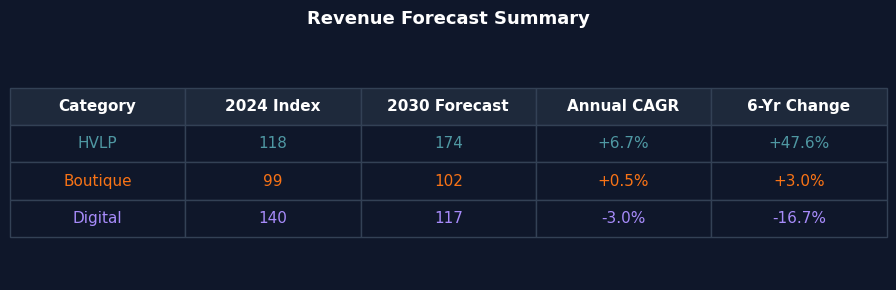

✅ Forecast table saved → output/forecast_table.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')
ax.axis('off')

table_data = []
for cat, d in revenue_data.items():
    table_data.append([
        cat,
        f"{d['hist'][-1]}",
        f"{d['forecast'][-1]:.0f}",
        f"{d['cagr']*100:+.1f}%",
        f"{((d['forecast'][-1]/d['hist'][-1])-1)*100:+.1f}%"
    ])

col_labels = ['Category', '2024 Index', '2030 Forecast', 'Annual CAGR', '6-Yr Change']
table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#334155')
    if r == 0:
        cell.set_facecolor('#1e293b')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cat = table_data[r-1][0]
        cell.set_facecolor('#0f172a')
        cell.set_text_props(color=colors.get(cat, '#94a3b8'))

ax.set_title('Revenue Forecast Summary', color='white',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'forecast_table.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Forecast table saved → output/forecast_table.png")